In [ ]:
# 🚦 USA Traffic Accident Analysis

### Data Analyst Portfolio Project

**Objective:**  
Analyze USA traffic accident data to identify accident patterns,
high-risk locations, time trends, and environmental factors.

**Tools:**  
Python | Pandas | NumPy | Matplotlib | Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
file_path = "../data/raw/USA_Accidents.csv"
print(file_path)

../data/raw/USA_Accidents.csv


In [3]:
df = pd.read_csv(
    file_path,
    nrows=100000
)

df.head()

,Unnamed: 0,ID,Start_Time,Start_Lat,Start_Lng,City,State,Temperature(F)
0,0,A-1,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,OH,36.9
1,1,A-2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,OH,37.9
2,2,A-3,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,OH,36.0
3,3,A-4,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,OH,35.1
4,4,A-5,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,OH,36.0


In [4]:
df.columns


Index(['Unnamed: 0', 'ID', 'Start_Time', 'Start_Lat', 'Start_Lng', 'City',
       'State', 'Temperature(F)'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      100000 non-null  int64  
 1   ID              100000 non-null  str    
 2   Start_Time      100000 non-null  str    
 3   Start_Lat       100000 non-null  float64
 4   Start_Lng       100000 non-null  float64
 5   City            99999 non-null   str    
 6   State           100000 non-null  str    
 7   Temperature(F)  98409 non-null   float64
dtypes: float64(3), int64(1), str(4)
memory usage: 6.1 MB


In [6]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])

In [7]:
missing_values = df.isnull().sum()

missing_values

Unnamed: 0           0
ID                   0
Start_Time           0
Start_Lat            0
Start_Lng            0
City                 1
State                0
Temperature(F)    1591
dtype: int64

In [8]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_percentage.sort_values(ascending=False)

Temperature(F)    1.591
City              0.001
Unnamed: 0        0.000
ID                0.000
Start_Lat         0.000
Start_Time        0.000
Start_Lng         0.000
State             0.000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
print("Unique Cities:", df["City"].nunique())
print("Unique States:", df["State"].nunique())

Unique Cities: 785
Unique States: 3


In [11]:
df["State"].value_counts()

State
CA    99272
OH      726
WV        2
Name: count, dtype: int64

In [12]:
df["ID"].duplicated().sum()


np.int64(0)

In [13]:
print("Total Records:", len(df))
print("Unique IDs:", df["ID"].nunique())

Total Records: 100000
Unique IDs: 100000


In [14]:
chunk_size = 100000

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    print(len(chunk))
    break
    

100000


In [15]:
total_rows = 0

for chunk in pd.read_csv(file_path, chunksize=100000):
    total_rows += len(chunk)

print("Total Rows:", total_rows)

Total Rows: 7728394


In [16]:
missing_counts = {}

for chunk in pd.read_csv(file_path, chunksize=100000):
    chunk_missing = chunk.isnull().sum()
    
    for column, count in chunk_missing.items():
        missing_counts[column] = missing_counts.get(column, 0) + count

missing_counts = pd.Series(missing_counts)

missing_counts.sort_values(ascending=False)

Temperature(F)    163853
City                 253
Unnamed: 0             0
ID                     0
Start_Lat              0
Start_Time             0
Start_Lng              0
State                  0
dtype: int64

In [17]:
unique_ids = set()
duplicate_id_count = 0

for chunk in pd.read_csv(file_path, chunksize=100000):
    ids = chunk["ID"]
    
    for accident_id in ids:
        if accident_id in unique_ids:
            duplicate_id_count += 1
        else:
            unique_ids.add(accident_id)

print("Duplicate IDs:", duplicate_id_count)
print("Unique IDs:", len(unique_ids))


Duplicate IDs: 0
Unique IDs: 7728394


In [18]:
df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()


,ID,Start_Time,Start_Lat,Start_Lng,City,State,Temperature(F)
0,A-1,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,OH,36.9
1,A-2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,OH,37.9
2,A-3,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,OH,36.0
3,A-4,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,OH,35.1
4,A-5,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,OH,36.0


In [19]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID              100000 non-null  str           
 1   Start_Time      100000 non-null  datetime64[us]
 2   Start_Lat       100000 non-null  float64       
 3   Start_Lng       100000 non-null  float64       
 4   City            99999 non-null   str           
 5   State           100000 non-null  str           
 6   Temperature(F)  98409 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 5.3 MB


In [20]:
df["Temperature(F)"] = df["Temperature(F)"].fillna(
    df["Temperature(F)"].median()
)

In [21]:
df.isnull().sum()

ID                0
Start_Time        0
Start_Lat         0
Start_Lng         0
City              1
State             0
Temperature(F)    0
dtype: int64

In [22]:
df["Year"] = df["Start_Time"].dt.year
df["Month"] = df["Start_Time"].dt.month
df["Month_Name"] = df["Start_Time"].dt.month_name()
df["Day_Name"] = df["Start_Time"].dt.day_name()
df["Hour"] = df["Start_Time"].dt.hour

In [23]:
df[
    [
        "Start_Time",
        "Year",
        "Month",
        "Month_Name",
        "Day_Name",
        "Hour"
    ]
].head()

,Start_Time,Year,Month,Month_Name,Day_Name,Hour
0,2016-02-08 05:46:00,2016,2,February,Monday,5
1,2016-02-08 06:07:59,2016,2,February,Monday,6
2,2016-02-08 06:49:27,2016,2,February,Monday,6
3,2016-02-08 07:23:34,2016,2,February,Monday,7
4,2016-02-08 07:39:07,2016,2,February,Monday,7


In [24]:
def get_time_period(hour):
    
    if 5 <= hour < 12:
        return "Morning"
    
    elif 12 <= hour < 17:
        return "Afternoon"
    
    elif 17 <= hour < 21:
        return "Evening"
    
    else:
        return "Night"

In [25]:
df["Time_Period"] = df["Hour"].apply(get_time_period)

In [26]:
df["Time_Period"].value_counts()


Time_Period
Morning      28718
Afternoon    26564
Evening      25305
Night        19413
Name: count, dtype: int64

In [27]:
df["Day_Type"] = np.where(
    df["Start_Time"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

In [28]:
df["Day_Type"].value_counts()

Day_Type
Weekday    84653
Weekend    15347
Name: count, dtype: int64

In [29]:
df["Year"].value_counts().sort_index()

Year
2016    90660
2017     9340
Name: count, dtype: int64

In [30]:
df["Month_Name"].value_counts()

Month_Name
November     13565
August       12899
September    12165
October      11550
December     10943
July         10096
January       9340
June          6268
April         5422
May           3760
March         3567
February       425
Name: count, dtype: int64

In [31]:
df["Day_Name"].value_counts()

Day_Name
Thursday     18008
Wednesday    17438
Tuesday      16988
Friday       16393
Monday       15826
Saturday      7994
Sunday        7353
Name: count, dtype: int64

In [32]:
df["Time_Period"].value_counts()

Time_Period
Morning      28718
Afternoon    26564
Evening      25305
Night        19413
Name: count, dtype: int64

In [33]:
df.describe()

,Start_Time,Start_Lat,Start_Lng,Temperature(F),Year,Month,Hour
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2016-09-13 05:06:10.255490,35.630369,-119.322756,66.631060,2016.093400,7.783670,13.503180
min,2016-02-08 05:46:00,32.542587,-123.813927,3.200000,2016.000000,1.000000,0.000000
25%,2016-07-19 10:51:31.250000,33.957775,-121.828468,57.900000,2016.000000,6.000000,10.000000
50%,2016-09-18 18:18:02,34.168579,-118.384232,66.000000,2016.000000,8.000000,14.000000
75%,2016-11-20 01:16:09.250000,37.776682,-117.916023,75.000000,2016.000000,10.000000,18.000000
max,2017-01-26 20:07:03,41.428753,-81.550728,114.100000,2017.000000,12.000000,23.000000
std,NaN,2.101259,3.663525,12.602636,0.290994,3.269195,5.778614


In [34]:
yearly_accidents = df["Year"].value_counts().sort_index()

yearly_accidents

Year
2016    90660
2017     9340
Name: count, dtype: int64

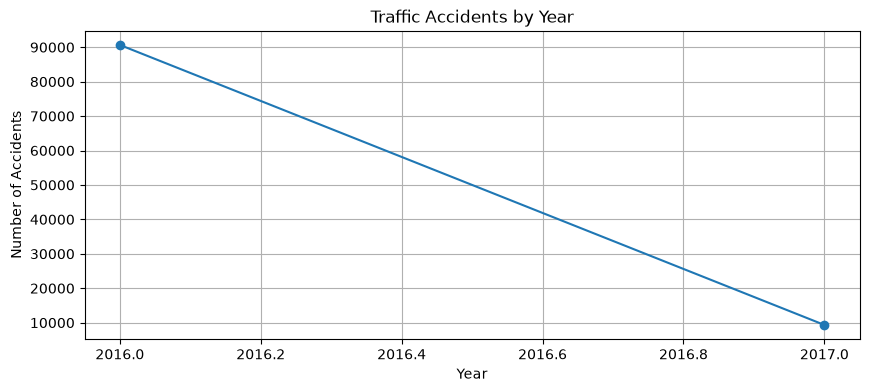

In [35]:
plt.figure(figsize=(10, 4))

yearly_accidents.plot(kind="line", marker="o")

plt.title("Traffic Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.grid(True)

plt.show()

In [36]:
monthly_accidents = (
    df.groupby("Month")
      .size()
)

monthly_accidents

Month
1      9340
2       425
3      3567
4      5422
5      3760
6      6268
7     10096
8     12899
9     12165
10    11550
11    13565
12    10943
dtype: int64

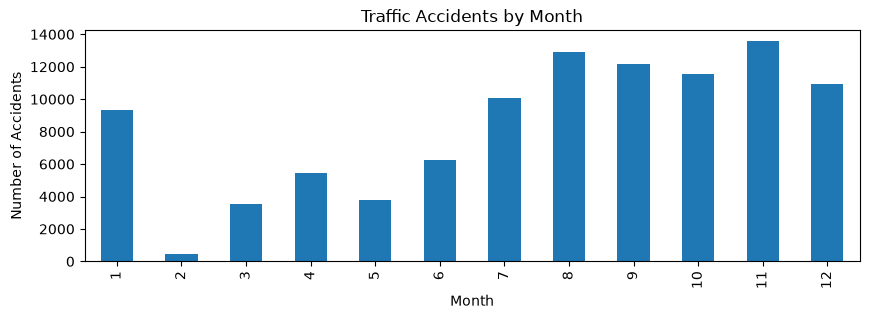

In [37]:
plt.figure(figsize=(10, 3))

monthly_accidents.plot(kind="bar")

plt.title("Traffic Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")

plt.show()

In [38]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_accidents = (
    df["Day_Name"]
    .value_counts()
    .reindex(day_order)
)

daily_accidents

Day_Name
Monday       15826
Tuesday      16988
Wednesday    17438
Thursday     18008
Friday       16393
Saturday      7994
Sunday        7353
Name: count, dtype: int64

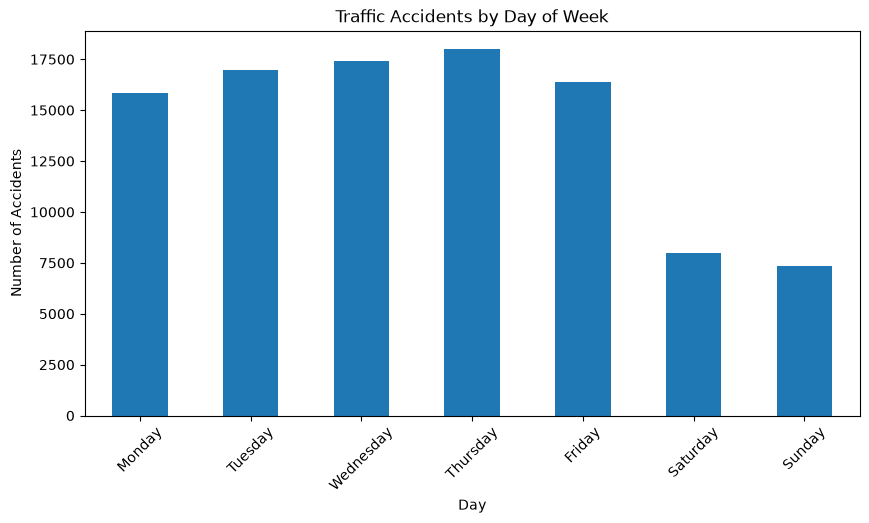

In [39]:
plt.figure(figsize=(10, 5))

daily_accidents.plot(kind="bar")

plt.title("Traffic Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.show()

In [40]:
hourly_accidents = (
    df["Hour"]
    .value_counts()
    .sort_index()
)

hourly_accidents

Hour
0     2240
1     1895
2     1895
3     1507
4     1303
5     1516
6     1378
7     2196
8     3142
9     5291
10    7285
11    7910
12    6219
13    5137
14    5208
15    4707
16    5293
17    5035
18    6144
19    6722
20    7404
21    4970
22    3773
23    1830
Name: count, dtype: int64

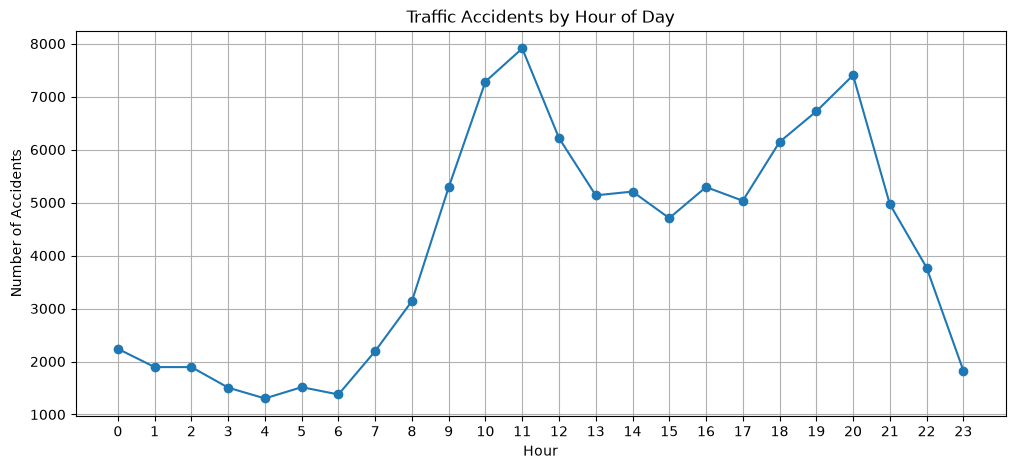

In [41]:
plt.figure(figsize=(12, 5))

hourly_accidents.plot(kind="line", marker="o")

plt.title("Traffic Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")

plt.xticks(range(0, 24))

plt.grid(True)

plt.show()

In [42]:
day_type_accidents = df["Day_Type"].value_counts()

day_type_accidents

Day_Type
Weekday    84653
Weekend    15347
Name: count, dtype: int64

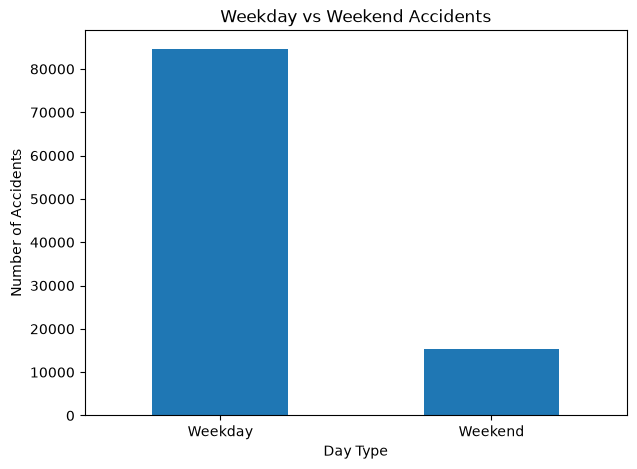

In [43]:
plt.figure(figsize=(7, 5))

day_type_accidents.plot(kind="bar")

plt.title("Weekday vs Weekend Accidents")
plt.xlabel("Day Type")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

In [44]:
top_cities = (
    df["City"]
    .value_counts()
    .head(10)
)

top_cities

City
Los Angeles      9792
Sacramento       5223
San Diego        3275
San Jose         3026
Oakland          1802
Long Beach       1343
San Francisco    1287
Riverside        1261
Corona           1095
Whittier         1019
Name: count, dtype: int64

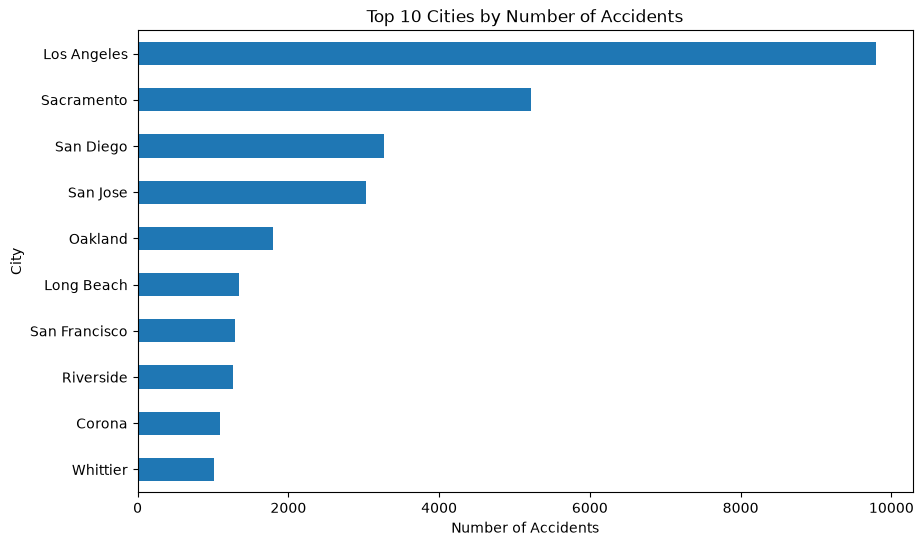

In [45]:
plt.figure(figsize=(10, 6))

top_cities.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("City")

plt.show()

In [46]:
state_accidents = (
    df["State"]
    .value_counts()
)

state_accidents

State
CA    99272
OH      726
WV        2
Name: count, dtype: int64

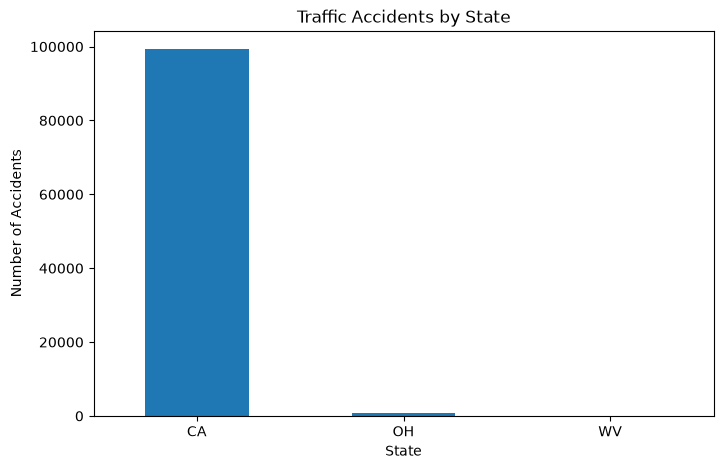

In [47]:
plt.figure(figsize=(8, 5))

state_accidents.plot(kind="bar")

plt.title("Traffic Accidents by State")
plt.xlabel("State")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

In [48]:
top_15_cities = (
    df.groupby("City")
      .size()
      .sort_values(ascending=False)
      .head(15)
      .reset_index(name="Accident_Count")
)

top_15_cities

,City,Accident_Count
0,Los Angeles,9792
1,Sacramento,5223
2,San Diego,3275
3,San Jose,3026
4,Oakland,1802
5,Long Beach,1343
6,San Francisco,1287
7,Riverside,1261
8,Corona,1095
9,Whittier,1019


<Figure size 1000x700 with 0 Axes>

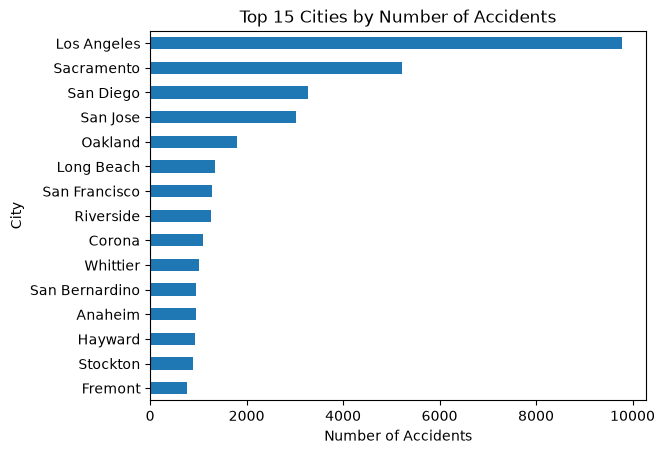

In [49]:
plt.figure(figsize=(10, 7))

top_15_cities.sort_values("Accident_Count").plot(
    x="City",
    y="Accident_Count",
    kind="barh",
    legend=False
)

plt.title("Top 15 Cities by Number of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("City")

plt.show()

In [50]:
df["Temperature(F)"].describe()

count    100000.000000
mean         66.631060
std          12.602636
min           3.200000
25%          57.900000
50%          66.000000
75%          75.000000
max         114.100000
Name: Temperature(F), dtype: float64

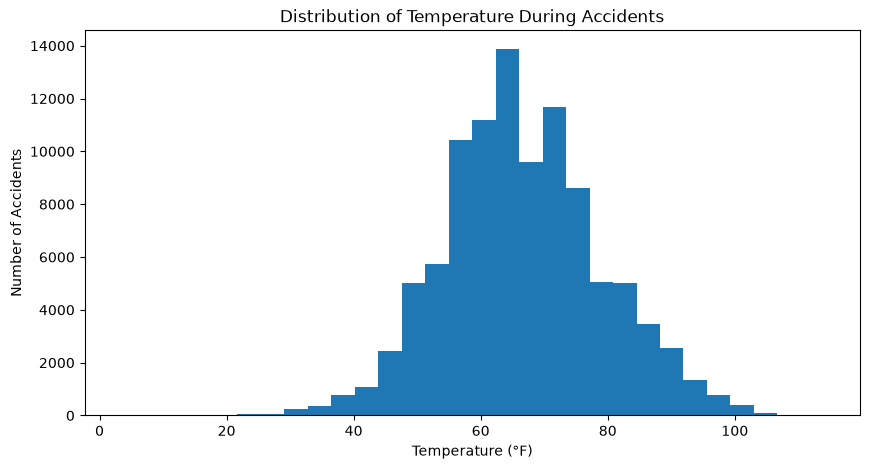

In [51]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Temperature(F)"],
    bins=30
)

plt.title("Distribution of Temperature During Accidents")
plt.xlabel("Temperature (°F)")
plt.ylabel("Number of Accidents")

plt.show()

In [52]:
temperature_bins = [
    -100,
    20,
    40,
    60,
    80,
    100,
    200
]

temperature_labels = [
    "<20°F",
    "20-40°F",
    "40-60°F",
    "60-80°F",
    "80-100°F",
    "100°F+"
]

df["Temperature_Range"] = pd.cut(
    df["Temperature(F)"],
    bins=temperature_bins,
    labels=temperature_labels
)

In [53]:
temperature_accidents = (
    df["Temperature_Range"]
    .value_counts()
    .sort_index()
)

temperature_accidents

Temperature_Range
<20°F          73
20-40°F      1515
40-60°F     28209
60-80°F     54628
80-100°F    15138
100°F+        437
Name: count, dtype: int64

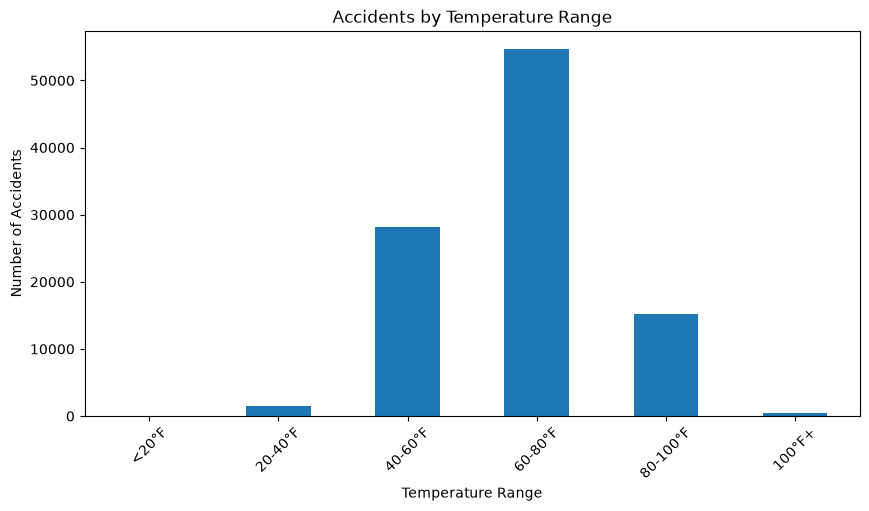

In [54]:
plt.figure(figsize=(10, 5))

temperature_accidents.plot(kind="bar")

plt.title("Accidents by Temperature Range")
plt.xlabel("Temperature Range")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.show()

In [55]:
day_hour = pd.crosstab(
    df["Day_Name"],
    df["Hour"]
)

day_hour = day_hour.reindex(day_order)

day_hour

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day_Name,,,,,,,,,,,,,,,,,,,,,
Monday,261,312,288,244,212,225,230,349,584,869,...,739,666,741,751,996,1049,1307,790,555,266
Tuesday,369,273,231,191,136,164,142,297,552,1043,...,802,686,745,821,1072,1163,1365,899,624,326
Wednesday,336,227,225,169,118,154,138,326,520,960,...,918,767,813,870,1119,1287,1362,908,696,287
Thursday,322,303,274,217,175,196,189,318,544,995,...,854,780,939,967,1197,1266,1428,979,737,331
Friday,380,314,281,223,174,234,188,331,456,775,...,827,755,919,976,1117,1214,1331,823,738,332
Saturday,354,160,294,206,247,273,237,240,243,334,...,593,558,571,341,391,411,360,313,222,129
Sunday,218,306,302,257,241,270,254,335,243,315,...,475,495,565,309,252,332,251,258,201,159


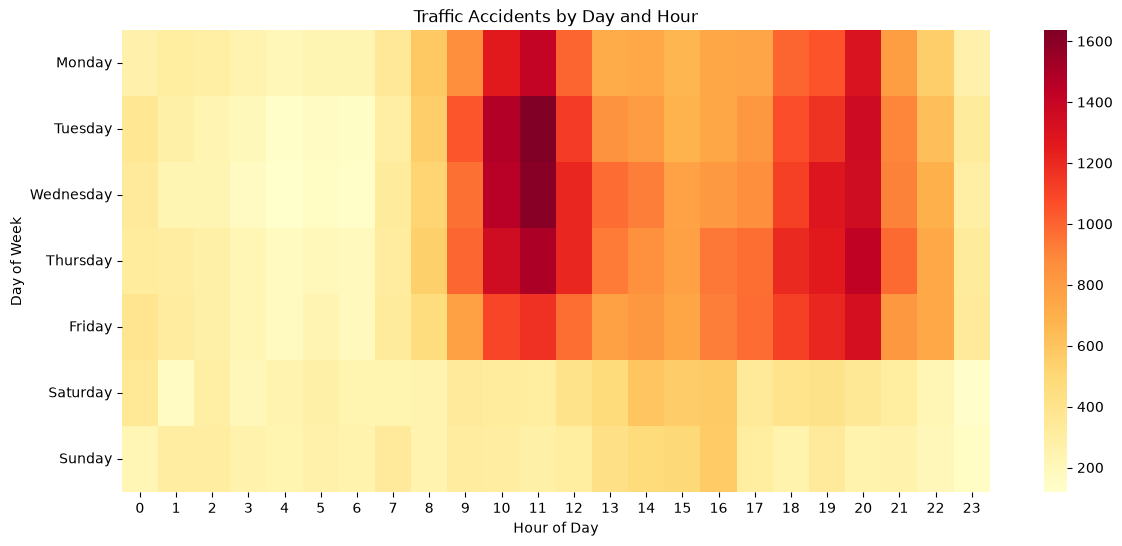

In [56]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    day_hour,
    cmap="YlOrRd"
)

plt.title("Traffic Accidents by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

In [57]:
top_hours = (
    df["Hour"]
    .value_counts()
    .head(5)
)

top_hours

Hour
11    7910
20    7404
10    7285
19    6722
12    6219
Name: count, dtype: int64

In [58]:
top_hours_percentage = (
    top_hours / len(df) * 100
).round(2)

top_hours_percentage

Hour
11    7.91
20    7.40
10    7.28
19    6.72
12    6.22
Name: count, dtype: float64

In [59]:
day_type_hour = pd.crosstab(
    df["Hour"],
    df["Day_Type"]
)

day_type_hour

Day_Type,Weekday,Weekend
Hour,,
0,1668,572
1,1429,466
2,1299,596
3,1044,463
4,815,488
5,973,543
6,887,491
7,1621,575
8,2656,486


<Figure size 1200x600 with 0 Axes>

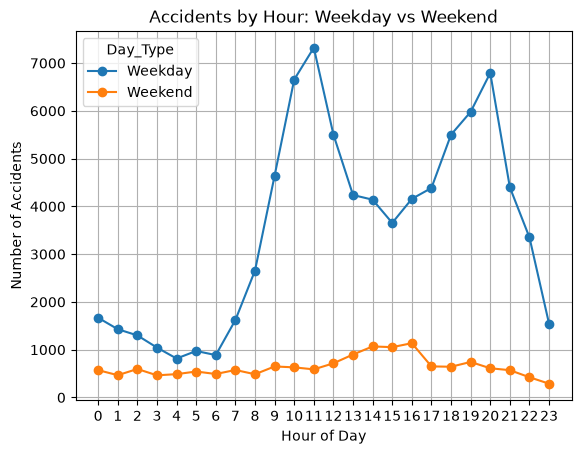

In [60]:
plt.figure(figsize=(12, 6))

day_type_hour.plot(
    kind="line",
    marker="o"
)

plt.title("Accidents by Hour: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")

plt.xticks(range(24))
plt.grid(True)

plt.show()

In [61]:
year_month = pd.crosstab(
    df["Year"],
    df["Month"]
)

year_month

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2016,0,425,3567,5422,3760,6268,10096,12899,12165,11550,13565,10943
2017,9340,0,0,0,0,0,0,0,0,0,0,0


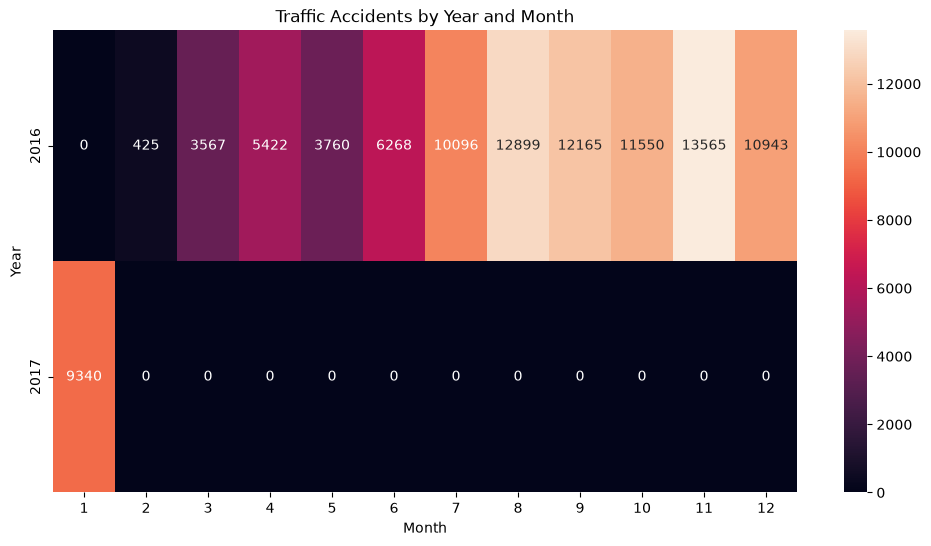

In [62]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    year_month,
    annot=True,
    fmt="d"
)

plt.title("Traffic Accidents by Year and Month")
plt.xlabel("Month")
plt.ylabel("Year")

plt.show()

In [63]:
df[
    ["Start_Lat", "Start_Lng"]
].describe()

,Start_Lat,Start_Lng
count,100000.000000,100000.000000
mean,35.630369,-119.322756
std,2.101259,3.663525
min,32.542587,-123.813927
25%,33.957775,-121.828468
50%,34.168579,-118.384232
75%,37.776682,-117.916023
max,41.428753,-81.550728


In [64]:
top_locations = (
    df.groupby(
        ["Start_Lat", "Start_Lng"]
    )
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Accident_Count")
)

top_locations

,Start_Lat,Start_Lng,Accident_Count
0,37.808498,-122.366852,162
1,33.941364,-118.096634,143
2,34.010056,-117.823219,122
3,33.876289,-118.102577,117
4,33.993450,-118.069351,105
5,34.064995,-118.000229,100
6,33.949665,-118.091896,98
7,34.019634,-117.988121,95
8,33.997040,-117.931015,94
9,33.968163,-118.167870,93


In [65]:
top_10_city_count = (
    df["City"]
    .value_counts()
    .head(10)
    .sum()
)

total_accidents = len(df)

top_10_city_percentage = (
    top_10_city_count / total_accidents * 100
)

print(
    "Top 10 Cities Accident Share:",
    round(top_10_city_percentage, 2),
    "%"
)

Top 10 Cities Accident Share: 29.12 %


In [66]:
Q1 = df["Temperature(F)"].quantile(0.25)
Q3 = df["Temperature(F)"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

temperature_outliers = df[
    (df["Temperature(F)"] < lower_bound) |
    (df["Temperature(F)"] > upper_bound)
]

print("Temperature Outliers:", len(temperature_outliers))

Temperature Outliers: 786


In [67]:
print(
    "Invalid Latitude:",
    ((df["Start_Lat"] < -90) | (df["Start_Lat"] > 90)).sum()
)

print(
    "Invalid Longitude:",
    ((df["Start_Lng"] < -180) | (df["Start_Lng"] > 180)).sum()
)

Invalid Latitude: 0
Invalid Longitude: 0


In [68]:
numeric_columns = [
    "Start_Lat",
    "Start_Lng",
    "Temperature(F)",
    "Hour",
    "Year",
    "Month"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Start_Lat,Start_Lng,Temperature(F),Hour,Year,Month
Start_Lat,1.000000,-0.366811,-0.225200,-0.002939,-0.023781,-0.137485
Start_Lng,-0.366811,1.000000,-0.031623,-0.032967,-0.009776,-0.058877
Temperature(F),-0.225200,-0.031623,1.000000,0.131275,-0.358228,0.096418
Hour,-0.002939,-0.032967,0.131275,1.000000,-0.016989,0.004953
Year,-0.023781,-0.009776,-0.358228,-0.016989,1.000000,-0.666027
Month,-0.137485,-0.058877,0.096418,0.004953,-0.666027,1.000000


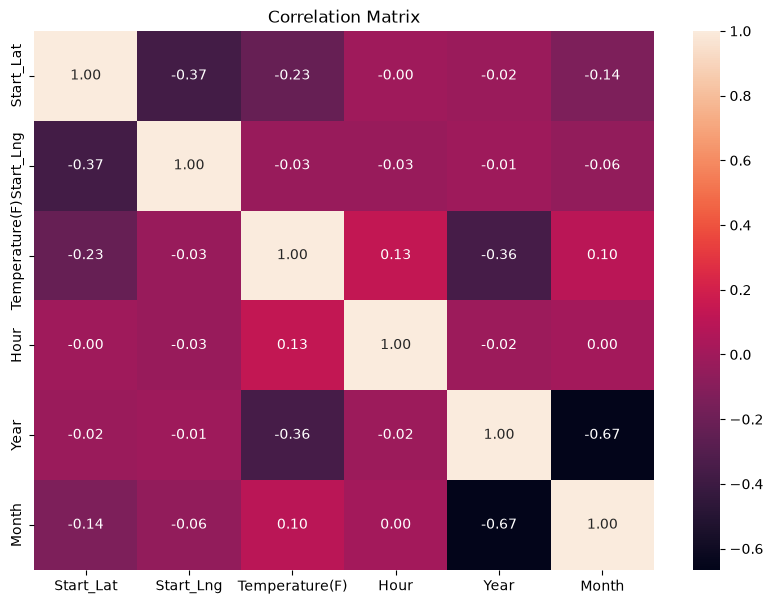

In [69]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [70]:
print("===== EDA SUMMARY =====")

print("Total Records:", len(df))

print("Unique Cities:", df["City"].nunique())

print("Unique States:", df["State"].nunique())

print(
    "Most Common Accident Hour:",
    df["Hour"].mode()[0]
)

print(
    "Most Common Accident Day:",
    df["Day_Name"].mode()[0]
)

print(
    "Most Common Time Period:",
    df["Time_Period"].mode()[0]
)

print(
    "Average Temperature:",
    round(df["Temperature(F)"].mean(), 2)
)

print(
    "Top Accident City:",
    df["City"].value_counts().index[0]
)

===== EDA SUMMARY =====
Total Records: 100000
Unique Cities: 785
Unique States: 3
Most Common Accident Hour: 11
Most Common Accident Day: Thursday
Most Common Time Period: Morning
Average Temperature: 66.63
Top Accident City: Los Angeles


In [71]:
required_columns = [
    "ID",
    "Start_Time",
    "Start_Lat",
    "Start_Lng",
    "City",
    "State",
    "Temperature(F)"
]

In [72]:
import os

os.makedirs("../data/processed", exist_ok=True)

In [73]:
input_file = "../data/raw/USA_Accidents.csv"
output_file = "../data/processed/USA_Accidents_Analytical.csv"

chunk_size = 100000

first_chunk = True

for chunk in pd.read_csv(
    input_file,
    usecols=required_columns,
    chunksize=chunk_size
):

    # Convert datetime
    chunk["Start_Time"] = pd.to_datetime(
        chunk["Start_Time"],
        errors="coerce"
    )

    # Clean text
    chunk["City"] = chunk["City"].fillna("Unknown").str.strip()
    chunk["State"] = chunk["State"].fillna("Unknown").str.strip()

    # Temperature
    chunk["Temperature(F)"] = chunk["Temperature(F)"].fillna(
        chunk["Temperature(F)"].median()
    )

    # Feature Engineering
    chunk["Year"] = chunk["Start_Time"].dt.year
    chunk["Month"] = chunk["Start_Time"].dt.month
    chunk["Month_Name"] = chunk["Start_Time"].dt.month_name()
    chunk["Day_Name"] = chunk["Start_Time"].dt.day_name()
    chunk["Hour"] = chunk["Start_Time"].dt.hour

    # Time Period
    chunk["Time_Period"] = np.select(
        [
            chunk["Hour"].between(5, 11),
            chunk["Hour"].between(12, 16),
            chunk["Hour"].between(17, 20)
        ],
        [
            "Morning",
            "Afternoon",
            "Evening"
        ],
        default="Night"
    )

    # Weekday / Weekend
    chunk["Day_Type"] = np.where(
        chunk["Start_Time"].dt.dayofweek >= 5,
        "Weekend",
        "Weekday"
    )

    # Save
    chunk.to_csv(
        output_file,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print("Full analytical dataset created successfully!")

Full analytical dataset created successfully!


In [74]:
import os

file_size = os.path.getsize(output_file) / (1024 * 1024)

print("File Size:", round(file_size, 2), "MB")

File Size: 808.73 MB


In [75]:
total_rows = 0

for chunk in pd.read_csv(
    output_file,
    chunksize=100000
):
    total_rows += len(chunk)

print("Total Analytical Rows:", total_rows)

Total Analytical Rows: 7728394


In [76]:
state_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["State"],
    chunksize=100000
):

    counts = chunk["State"].value_counts()

    for state, count in counts.items():
        state_counts[state] = state_counts.get(state, 0) + count

state_counts = pd.Series(state_counts).sort_values(
    ascending=False
)

state_counts.head(20)

CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
AZ     170609
GA     169234
IL     168958
TN     167388
MI     162191
LA     149701
NJ     140719
MD     140417
OH     118115
WA     108221
dtype: int64

In [77]:
city_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["City"],
    chunksize=100000
):

    counts = chunk["City"].value_counts()

    for city, count in counts.items():
        city_counts[city] = city_counts.get(city, 0) + count

city_counts = pd.Series(city_counts).sort_values(
    ascending=False
)

city_counts.head(20)

Miami            186917
Houston          169609
Los Angeles      156491
Charlotte        138652
Dallas           130939
Orlando          109733
Austin            97359
Raleigh           86079
Nashville         72930
Baton Rouge       71588
Atlanta           68186
Sacramento        66264
San Diego         55504
Phoenix           53974
Minneapolis       51488
Richmond          48845
Oklahoma City     46092
Jacksonville      42447
Tucson            39304
Columbia          38178
dtype: int64

In [78]:
year_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["Year"],
    chunksize=100000
):

    counts = chunk["Year"].value_counts()

    for year, count in counts.items():
        year_counts[year] = year_counts.get(year, 0) + count

year_counts = pd.Series(year_counts).sort_index()

year_counts

2016.0     410820
2017.0     717290
2018.0     893425
2019.0     954302
2020.0    1161568
2021.0    1257835
2022.0    1125487
2023.0     146923
dtype: int64

In [79]:
total_accidents = 0
unique_cities = set()
unique_states = set()

temperature_sum = 0
temperature_count = 0

min_year = None
max_year = None

for chunk in pd.read_csv(
    output_file,
    chunksize=100000
):
    
    total_accidents += len(chunk)
    
    unique_cities.update(chunk["City"].dropna().unique())
    unique_states.update(chunk["State"].dropna().unique())
    
    temperature_sum += chunk["Temperature(F)"].sum()
    temperature_count += chunk["Temperature(F)"].count()
    
    chunk_min_year = chunk["Year"].min()
    chunk_max_year = chunk["Year"].max()
    
    if min_year is None or chunk_min_year < min_year:
        min_year = chunk_min_year
        
    if max_year is None or chunk_max_year > max_year:
        max_year = chunk_max_year


average_temperature = temperature_sum / temperature_count

print("Total Accidents:", total_accidents)
print("Unique Cities:", len(unique_cities))
print("Unique States:", len(unique_states))
print("Average Temperature:", round(average_temperature, 2))
print("Start Year:", min_year)
print("End Year:", max_year)

Total Accidents: 7728394
Unique Cities: 13679
Unique States: 49
Average Temperature: 61.7
Start Year: 2016
End Year: 2023.0


In [80]:
year_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["Year"],
    chunksize=100000
):
    
    counts = chunk["Year"].value_counts()
    
    for year, count in counts.items():
        year_counts[year] = year_counts.get(year, 0) + count

year_counts = pd.Series(year_counts).sort_index()

year_counts

2016.0     410820
2017.0     717290
2018.0     893425
2019.0     954302
2020.0    1161568
2021.0    1257835
2022.0    1125487
2023.0     146923
dtype: int64

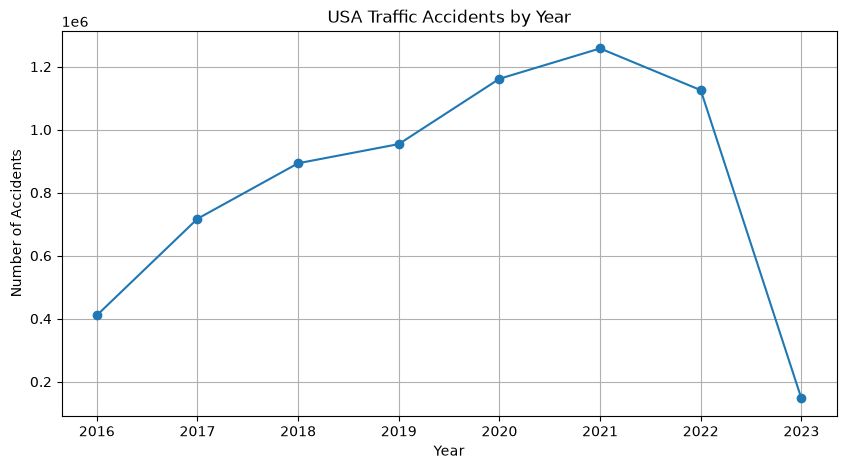

In [81]:
plt.figure(figsize=(10, 5))

year_counts.plot(
    kind="line",
    marker="o"
)

plt.title("USA Traffic Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")

plt.grid(True)

plt.show()

In [82]:
state_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["State"],
    chunksize=100000
):
    
    counts = chunk["State"].value_counts()
    
    for state, count in counts.items():
        state_counts[state] = state_counts.get(state, 0) + count

state_counts = pd.Series(
    state_counts
).sort_values(
    ascending=False
)

state_counts.head(15)

CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
AZ     170609
GA     169234
IL     168958
TN     167388
MI     162191
dtype: int64

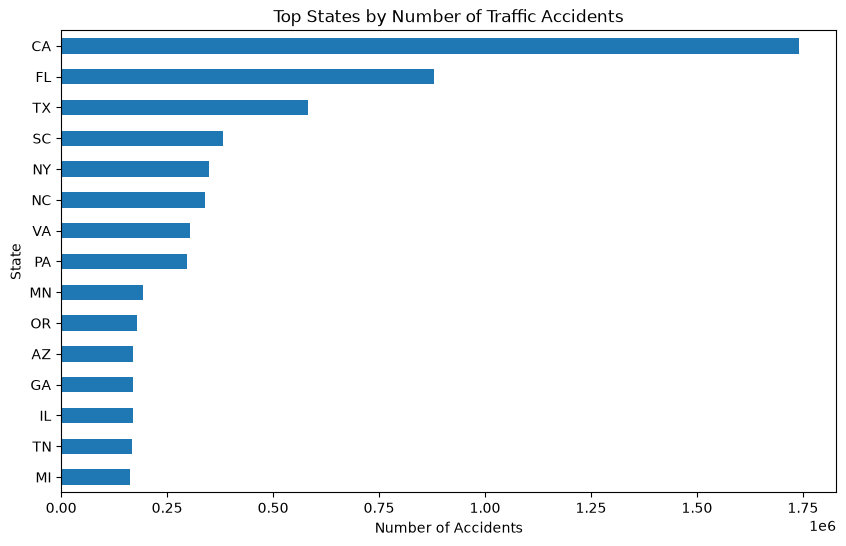

In [83]:
plt.figure(figsize=(10, 6))

state_counts.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top States by Number of Traffic Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("State")

plt.show()

In [84]:
city_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["City"],
    chunksize=100000
):
    
    counts = chunk["City"].value_counts()
    
    for city, count in counts.items():
        city_counts[city] = city_counts.get(city, 0) + count

city_counts = pd.Series(
    city_counts
).sort_values(
    ascending=False
)

city_counts.head(20)

Miami            186917
Houston          169609
Los Angeles      156491
Charlotte        138652
Dallas           130939
Orlando          109733
Austin            97359
Raleigh           86079
Nashville         72930
Baton Rouge       71588
Atlanta           68186
Sacramento        66264
San Diego         55504
Phoenix           53974
Minneapolis       51488
Richmond          48845
Oklahoma City     46092
Jacksonville      42447
Tucson            39304
Columbia          38178
dtype: int64

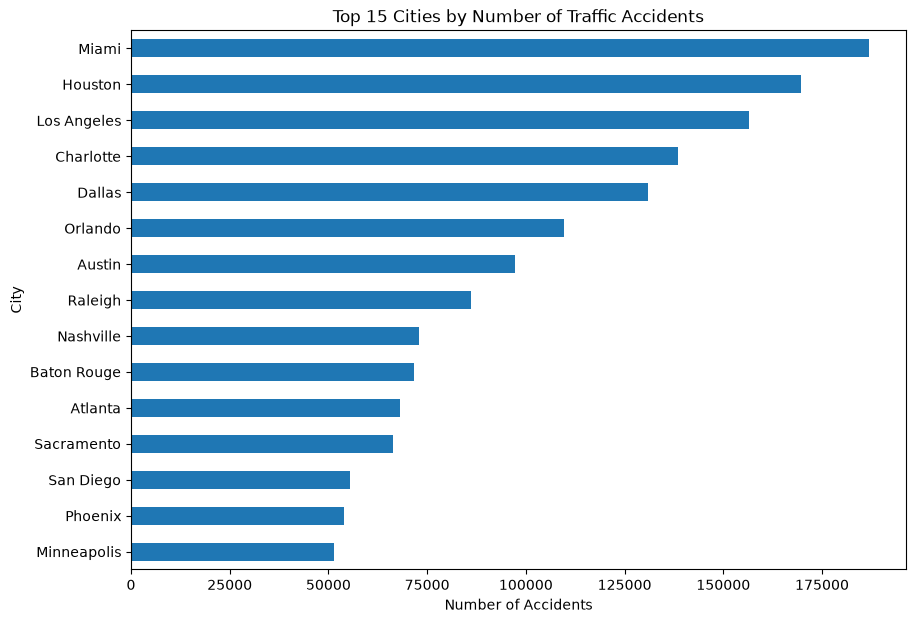

In [85]:
plt.figure(figsize=(10, 7))

city_counts.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Cities by Number of Traffic Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("City")

plt.show()

In [86]:
hour_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["Hour"],
    chunksize=100000
):
    
    counts = chunk["Hour"].value_counts()
    
    for hour, count in counts.items():
        hour_counts[hour] = hour_counts.get(hour, 0) + count

hour_counts = pd.Series(
    hour_counts
).sort_index()

hour_counts

0      93151
1      81449
2      78316
3      70407
4     144491
5     201248
6     361910
7     530109
8     526881
9     321750
10    301087
11    308009
12    299931
13    333261
14    370732
15    436105
16    493084
17    490180
18    372708
19    254979
20    192125
21    160474
22    140927
23    104336
dtype: int64

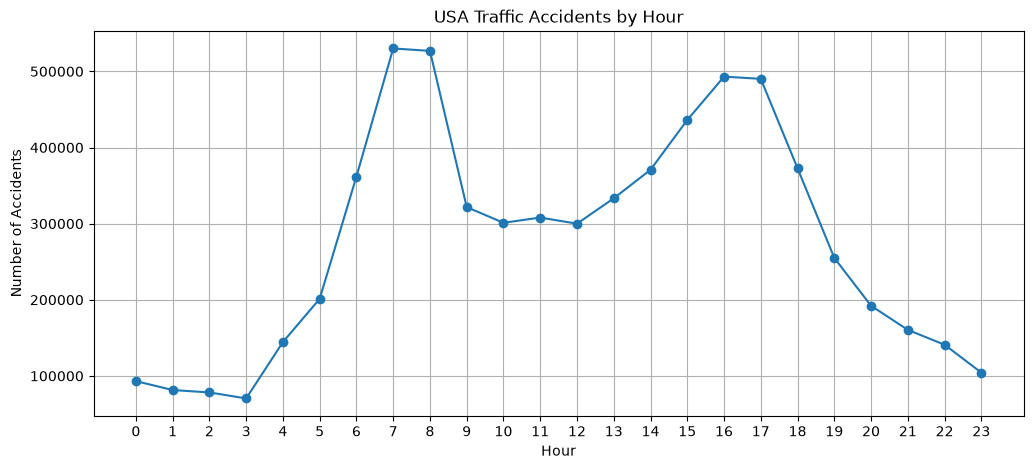

In [87]:
plt.figure(figsize=(12, 5))

hour_counts.plot(
    kind="line",
    marker="o"
)

plt.title("USA Traffic Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")

plt.xticks(range(24))
plt.grid(True)

plt.show()

In [88]:
top_hour = hour_counts.idxmax()
top_hour_count = hour_counts.max()

print("Peak Accident Hour:", top_hour)
print("Accidents at Peak Hour:", top_hour_count)

Peak Accident Hour: 7
Accidents at Peak Hour: 530109


In [89]:
peak_hour_percentage = (
    top_hour_count / total_accidents * 100
)

print(
    "Peak Hour Share:",
    round(peak_hour_percentage, 2),
    "%"
)

Peak Hour Share: 6.86 %


In [90]:
day_counts = {}

for chunk in pd.read_csv(
    output_file,
    chunksize=100000
):
    
    counts = chunk["Day_Name"].value_counts()
    
    for day, count in counts.items():
        day_counts[day] = day_counts.get(day, 0) + count

day_counts = pd.Series(day_counts)

day_counts = day_counts.reindex(day_order)

day_counts

Monday       1064726
Tuesday      1130489
Wednesday    1145450
Thursday     1145373
Friday       1181970
Saturday      540244
Sunday        459398
dtype: int64

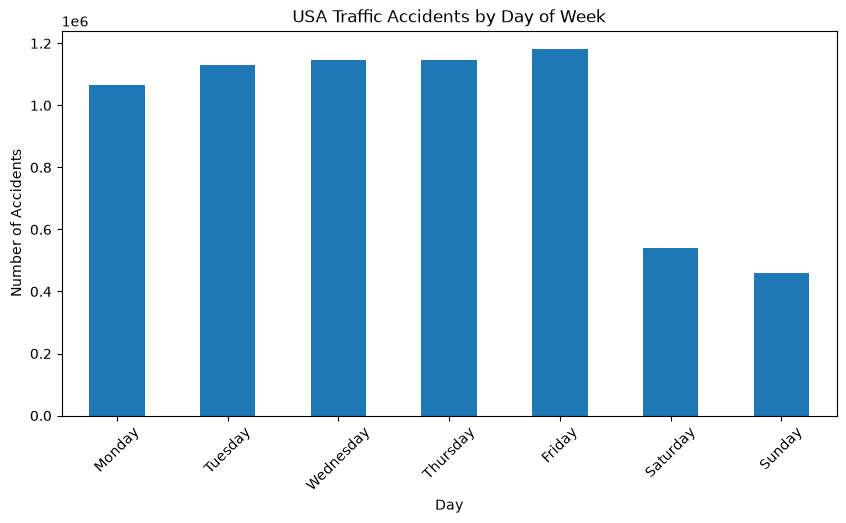

In [91]:
plt.figure(figsize=(10, 5))

day_counts.plot(kind="bar")

plt.title("USA Traffic Accidents by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.show()

In [92]:
month_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["Month"],
    chunksize=100000
):
    
    counts = chunk["Month"].value_counts()
    
    for month, count in counts.items():
        month_counts[month] = month_counts.get(month, 0) + count

month_counts = pd.Series(month_counts).sort_index()

month_counts

1     624280
2     565268
3     481553
4     501215
5     482771
6     499618
7     439187
8     521103
9     565315
10    605753
11    663741
12    717846
dtype: int64

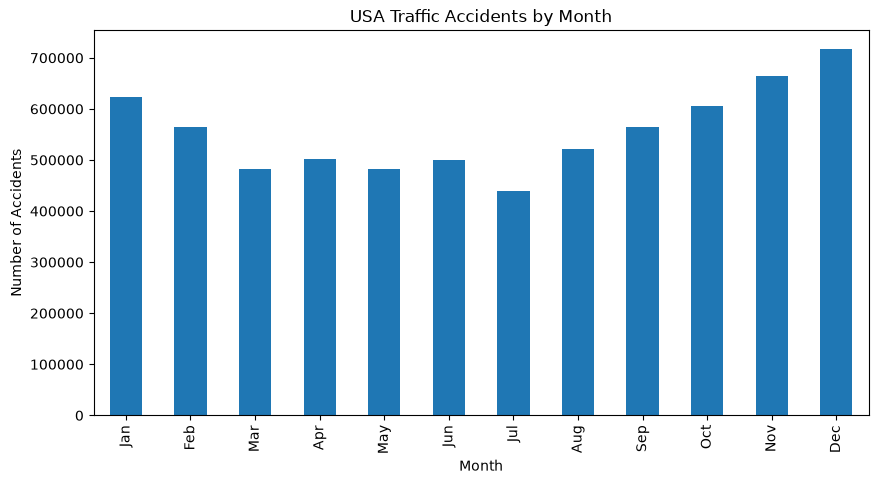

In [93]:
plt.figure(figsize=(10, 5))

month_counts.plot(kind="bar")

plt.title("USA Traffic Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")

plt.xticks(range(12), [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])

plt.show()

In [94]:
time_period_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["Time_Period"],
    chunksize=100000
):
    
    counts = chunk["Time_Period"].value_counts()
    
    for period, count in counts.items():
        time_period_counts[period] = (
            time_period_counts.get(period, 0) + count
        )

time_period_counts = pd.Series(
    time_period_counts
).sort_values(ascending=False)

time_period_counts

Morning      2550994
Night        1934295
Afternoon    1933113
Evening      1309992
dtype: int64

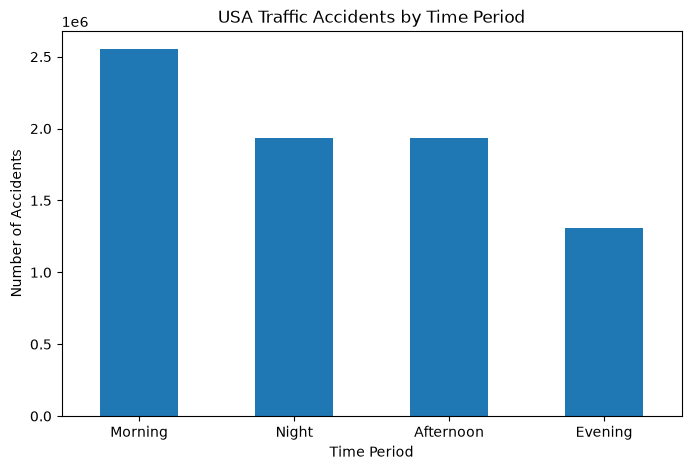

In [95]:
plt.figure(figsize=(8, 5))

time_period_counts.plot(kind="bar")

plt.title("USA Traffic Accidents by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

In [96]:
day_type_counts = {}

for chunk in pd.read_csv(
    output_file,
    usecols=["Day_Type"],
    chunksize=100000
):
    
    counts = chunk["Day_Type"].value_counts()
    
    for day_type, count in counts.items():
        day_type_counts[day_type] = (
            day_type_counts.get(day_type, 0) + count
        )

day_type_counts = pd.Series(day_type_counts)

day_type_counts

Weekday    6728752
Weekend     999642
dtype: int64

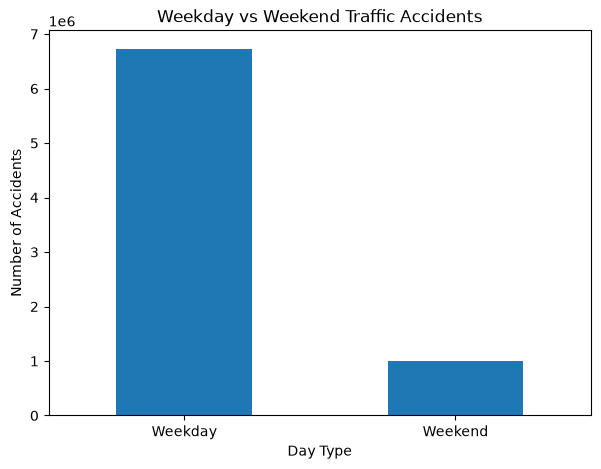

In [97]:
plt.figure(figsize=(7, 5))

day_type_counts.plot(kind="bar")

plt.title("Weekday vs Weekend Traffic Accidents")
plt.xlabel("Day Type")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=0)

plt.show()

In [98]:
day_type_percentage = (
    day_type_counts / total_accidents * 100
).round(2)

day_type_percentage

Weekday    87.07
Weekend    12.93
dtype: float64

In [99]:
temperature_sum = 0
temperature_count = 0

for chunk in pd.read_csv(
    output_file,
    usecols=["Temperature(F)"],
    chunksize=100000
):
    
    temperature_sum += chunk["Temperature(F)"].sum()
    temperature_count += chunk["Temperature(F)"].count()

full_avg_temperature = (
    temperature_sum / temperature_count
)

print(
    "Average Temperature:",
    round(full_avg_temperature, 2),
    "°F"
)

Average Temperature: 61.7 °F


In [100]:
temperature_range_counts = {}

bins = [-100, 20, 40, 60, 80, 100, 200]

labels = [
    "<20°F",
    "20-40°F",
    "40-60°F",
    "60-80°F",
    "80-100°F",
    "100°F+"
]

for chunk in pd.read_csv(
    output_file,
    usecols=["Temperature(F)"],
    chunksize=100000
):
    
    temp_range = pd.cut(
        chunk["Temperature(F)"],
        bins=bins,
        labels=labels
    )
    
    counts = temp_range.value_counts()
    
    for category, count in counts.items():
        temperature_range_counts[category] = (
            temperature_range_counts.get(category, 0) + count
        )

temperature_range_counts = pd.Series(
    temperature_range_counts
).reindex(labels)

temperature_range_counts

<20°F        167369
20-40°F      947892
40-60°F     2194706
60-80°F     3134922
80-100°F    1257413
100°F+        26088
dtype: int64

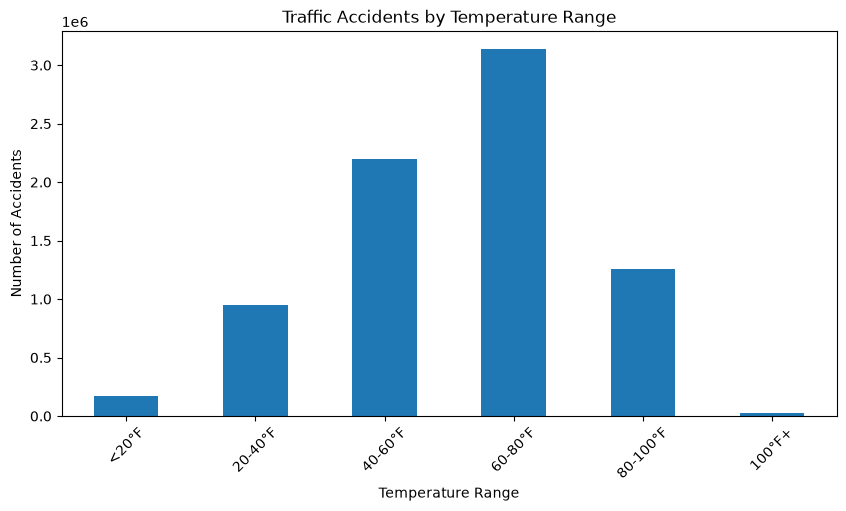

In [101]:
plt.figure(figsize=(10, 5))

temperature_range_counts.plot(kind="bar")

plt.title("Traffic Accidents by Temperature Range")
plt.xlabel("Temperature Range")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)

plt.show()

In [102]:
print("========== USA TRAFFIC ACCIDENT ANALYSIS ==========")

print("Total Accidents:", total_accidents)

print("Unique States:", len(unique_states))

print("Unique Cities:", len(unique_cities))

print(
    "Average Temperature:",
    round(full_avg_temperature, 2),
    "°F"
)

print(
    "Peak Accident Hour:",
    hour_counts.idxmax()
)

print(
    "Peak Hour Accident Count:",
    hour_counts.max()
)

print(
    "Highest Accident State:",
    state_counts.idxmax()
)

print(
    "Highest Accident State Count:",
    state_counts.max()
)

print(
    "Highest Accident City:",
    city_counts.idxmax()
)

print(
    "Highest Accident City Count:",
    city_counts.max()
)

print(
    "Highest Accident Day:",
    day_counts.idxmax()
)

print(
    "Highest Accident Month:",
    month_counts.idxmax()
)

print(
    "Highest Accident Time Period:",
    time_period_counts.idxmax()
)

print("===================================================")

========== USA TRAFFIC ACCIDENT ANALYSIS ==========
Total Accidents: 7728394
Unique States: 49
Unique Cities: 13679
Average Temperature: 61.7 °F
Peak Accident Hour: 7
Peak Hour Accident Count: 530109
Highest Accident State: CA
Highest Accident State Count: 1741433
Highest Accident City: Miami
Highest Accident City Count: 186917
Highest Accident Day: Friday
Highest Accident Month: 12
Highest Accident Time Period: Morning


In [103]:
import sqlite3

db_path = "../data/USA_Traffic_Accidents.db"

conn = sqlite3.connect(db_path)

print("SQLite database connected successfully!")

SQLite database connected successfully!


In [104]:
chunk_size = 100000

first_chunk = True

for chunk in pd.read_csv(
    output_file,
    chunksize=chunk_size
):
    
    chunk.to_sql(
        "traffic_accidents",
        conn,
        if_exists="replace" if first_chunk else "append",
        index=False
    )
    
    first_chunk = False

print("Data loaded into SQL successfully!")

Data loaded into SQL successfully!


In [105]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

tables

,name
0,traffic_accidents


In [106]:
pd.read_sql_query(
    """
    SELECT COUNT(*) AS total_accidents
    FROM traffic_accidents;
    """,
    conn
)

,total_accidents
0,7728394


In [107]:
query = """
SELECT *
FROM traffic_accidents
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,ID,Start_Time,Start_Lat,Start_Lng,City,State,Temperature(F),Year,Month,Month_Name,Day_Name,Hour,Time_Period,Day_Type
0,A-1,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,OH,36.9,2016,2,February,Monday,5,Morning,Weekday
1,A-2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,OH,37.9,2016,2,February,Monday,6,Morning,Weekday
2,A-3,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,OH,36.0,2016,2,February,Monday,6,Morning,Weekday
3,A-4,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,OH,35.1,2016,2,February,Monday,7,Morning,Weekday
4,A-5,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,OH,36.0,2016,2,February,Monday,7,Morning,Weekday
5,A-6,2016-02-08 07:44:26,40.100590,-82.925194,Westerville,OH,37.9,2016,2,February,Monday,7,Morning,Weekday
6,A-7,2016-02-08 07:59:35,39.758274,-84.230507,Dayton,OH,34.0,2016,2,February,Monday,7,Morning,Weekday
7,A-8,2016-02-08 07:59:58,39.770382,-84.194901,Dayton,OH,34.0,2016,2,February,Monday,7,Morning,Weekday
8,A-9,2016-02-08 08:00:40,39.778061,-84.172005,Dayton,OH,33.3,2016,2,February,Monday,8,Morning,Weekday
9,A-10,2016-02-08 08:10:04,40.100590,-82.925194,Westerville,OH,37.4,2016,2,February,Monday,8,Morning,Weekday


In [108]:
query = """
SELECT COUNT(*) AS total_accidents
FROM traffic_accidents;
"""

pd.read_sql_query(query, conn)

,total_accidents
0,7728394


In [109]:
query = """
SELECT
    State,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY State
ORDER BY accident_count DESC;
"""

pd.read_sql_query(query, conn)

,State,accident_count
0,CA,1741433
1,FL,880192
2,TX,582837
3,SC,382557
4,NY,347960
5,NC,338199
6,VA,303301
7,PA,296620
8,MN,192084
9,OR,179660


In [110]:
query = """
SELECT
    City,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY City
ORDER BY accident_count DESC
LIMIT 10;
"""

top_10_cities_sql = pd.read_sql_query(query, conn)

top_10_cities_sql

,City,accident_count
0,Miami,186917
1,Houston,169609
2,Los Angeles,156491
3,Charlotte,138652
4,Dallas,130939
5,Orlando,109733
6,Austin,97359
7,Raleigh,86079
8,Nashville,72930
9,Baton Rouge,71588


In [111]:
query = """
SELECT
    Year,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY Year
ORDER BY Year;
"""

pd.read_sql_query(query, conn)

,Year,accident_count
0,NaN,1060744
1,2016.0,410820
2,2017.0,717290
3,2018.0,893425
4,2019.0,954302
5,2020.0,1161568
6,2021.0,1257835
7,2022.0,1125487
8,2023.0,146923


In [112]:
query = """
SELECT
    State,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY State
ORDER BY accident_count DESC
LIMIT 10;
"""

top_states = pd.read_sql_query(query, conn)

top_states


,State,accident_count
0,CA,1741433
1,FL,880192
2,TX,582837
3,SC,382557
4,NY,347960
5,NC,338199
6,VA,303301
7,PA,296620
8,MN,192084
9,OR,179660


In [113]:
query = """
SELECT
    State,
    ROUND(AVG("Temperature(F)"), 2) AS avg_temperature
FROM traffic_accidents
GROUP BY State
ORDER BY avg_temperature DESC;
"""

avg_temp_state = pd.read_sql_query(query, conn)

avg_temp_state

,State,avg_temperature
0,FL,75.19
1,AZ,72.55
2,LA,69.97
3,TX,69.81
4,AL,66.46
5,MS,66.11
6,SC,64.52
7,GA,64.29
8,CA,63.85
9,OK,63.81


In [114]:
query = """
SELECT
    Month,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY Month
ORDER BY Month;
"""

monthly_sql = pd.read_sql_query(query, conn)

monthly_sql

,Month,accident_count
0,NaN,1060744
1,1.0,624280
2,2.0,565268
3,3.0,481553
4,4.0,501215
5,5.0,482771
6,6.0,499618
7,7.0,439187
8,8.0,521103
9,9.0,565315


In [115]:
query = """
SELECT
    Day_Name,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY Day_Name
ORDER BY accident_count DESC;
"""

daily_sql = pd.read_sql_query(query, conn)

daily_sql

,Day_Name,accident_count
0,Friday,1181970
1,Wednesday,1145450
2,Thursday,1145373
3,Tuesday,1130489
4,Monday,1064726
5,NaN,1060744
6,Saturday,540244
7,Sunday,459398


In [116]:
query = """
SELECT
    Hour,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY Hour
ORDER BY accident_count DESC
LIMIT 1;
"""

peak_hour_sql = pd.read_sql_query(query, conn)

peak_hour_sql

,Hour,accident_count
0,None,1060744


In [117]:
query = """
SELECT
    Day_Type,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY Day_Type
ORDER BY accident_count DESC;
"""

weekday_weekend_sql = pd.read_sql_query(query, conn)

weekday_weekend_sql

,Day_Type,accident_count
0,Weekday,6728752
1,Weekend,999642


In [118]:
query = """
SELECT
    Time_Period,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY Time_Period
ORDER BY accident_count DESC;
"""

time_period_sql = pd.read_sql_query(query, conn)

time_period_sql


,Time_Period,accident_count
0,Morning,2550994
1,Night,1934295
2,Afternoon,1933113
3,Evening,1309992


In [119]:
query = """
SELECT
    State,
    City,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY State, City
ORDER BY State, accident_count DESC;
"""

state_city_sql = pd.read_sql_query(query, conn)

state_city_sql.head(20)

,State,City,accident_count
0,AL,Birmingham,16935
1,AL,Montgomery,10373
2,AL,Huntsville,8094
3,AL,Mobile,6895
4,AL,Tuscaloosa,6779
5,AL,Madison,2338
6,AL,Northport,2070
7,AL,Clanton,1815
8,AL,Dothan,1761
9,AL,Prattville,1501


In [120]:
query = """
SELECT
    State,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY State
HAVING COUNT(*) > 100000
ORDER BY accident_count DESC;
"""

high_accident_states = pd.read_sql_query(query, conn)

high_accident_states


,State,accident_count
0,CA,1741433
1,FL,880192
2,TX,582837
3,SC,382557
4,NY,347960
5,NC,338199
6,VA,303301
7,PA,296620
8,MN,192084
9,OR,179660


In [121]:
query = """
SELECT
    State,
    COUNT(*) AS accident_count,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM traffic_accidents),
        2
    ) AS accident_percentage
FROM traffic_accidents
GROUP BY State
ORDER BY accident_percentage DESC;
"""

state_percentage = pd.read_sql_query(query, conn)

state_percentage


,State,accident_count,accident_percentage
0,CA,1741433,22.53
1,FL,880192,11.39
2,TX,582837,7.54
3,SC,382557,4.95
4,NY,347960,4.50
5,NC,338199,4.38
6,VA,303301,3.92
7,PA,296620,3.84
8,MN,192084,2.49
9,OR,179660,2.32


In [122]:
query = """
SELECT
    CASE
        WHEN Hour BETWEEN 5 AND 11 THEN 'Morning'
        WHEN Hour BETWEEN 12 AND 16 THEN 'Afternoon'
        WHEN Hour BETWEEN 17 AND 20 THEN 'Evening'
        ELSE 'Night'
    END AS time_category,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY time_category
ORDER BY accident_count DESC;
"""

hour_category_sql = pd.read_sql_query(query, conn)

hour_category_sql


,time_category,accident_count
0,Morning,2550994
1,Night,1934295
2,Afternoon,1933113
3,Evening,1309992


In [123]:
query = """
WITH state_accidents AS (
    SELECT
        State,
        COUNT(*) AS accident_count
    FROM traffic_accidents
    GROUP BY State
)

SELECT
    State,
    accident_count
FROM state_accidents
WHERE accident_count > (
    SELECT AVG(accident_count)
    FROM state_accidents
)
ORDER BY accident_count DESC;
"""

above_average_states = pd.read_sql_query(query, conn)

above_average_states

,State,accident_count
0,CA,1741433
1,FL,880192
2,TX,582837
3,SC,382557
4,NY,347960
5,NC,338199
6,VA,303301
7,PA,296620
8,MN,192084
9,OR,179660


In [124]:
query = """
SELECT
    State,
    COUNT(*) AS accident_count,
    RANK() OVER (
        ORDER BY COUNT(*) DESC
    ) AS state_rank
FROM traffic_accidents
GROUP BY State
ORDER BY state_rank;
"""

state_rank_sql = pd.read_sql_query(query, conn)

state_rank_sql


,State,accident_count,state_rank
0,CA,1741433,1
1,FL,880192,2
2,TX,582837,3
3,SC,382557,4
4,NY,347960,5
5,NC,338199,6
6,VA,303301,7
7,PA,296620,8
8,MN,192084,9
9,OR,179660,10


In [125]:
query = """
WITH city_accidents AS (
    SELECT
        State,
        City,
        COUNT(*) AS accident_count
    FROM traffic_accidents
    GROUP BY State, City
)

SELECT
    State,
    City,
    accident_count,
    RANK() OVER (
        PARTITION BY State
        ORDER BY accident_count DESC
    ) AS city_rank
FROM city_accidents
ORDER BY State, city_rank;
"""

city_rank_sql = pd.read_sql_query(query, conn)

city_rank_sql.head(30)

,State,City,accident_count,city_rank
0,AL,Birmingham,16935,1
1,AL,Montgomery,10373,2
2,AL,Huntsville,8094,3
3,AL,Mobile,6895,4
4,AL,Tuscaloosa,6779,5
5,AL,Madison,2338,6
6,AL,Northport,2070,7
7,AL,Clanton,1815,8
8,AL,Dothan,1761,9
9,AL,Prattville,1501,10


In [126]:
query = """
WITH city_accidents AS (
    SELECT
        State,
        City,
        COUNT(*) AS accident_count
    FROM traffic_accidents
    GROUP BY State, City
),

ranked_cities AS (
    SELECT
        State,
        City,
        accident_count,
        RANK() OVER (
            PARTITION BY State
            ORDER BY accident_count DESC
        ) AS city_rank
    FROM city_accidents
)

SELECT
    State,
    City,
    accident_count,
    city_rank
FROM ranked_cities
WHERE city_rank <= 3
ORDER BY State, city_rank;
"""

top_3_cities = pd.read_sql_query(query, conn)

top_3_cities

,State,City,accident_count,city_rank
0,AL,Birmingham,16935,1
1,AL,Montgomery,10373,2
2,AL,Huntsville,8094,3
3,AR,Little Rock,4373,1
4,AR,North Little Rock,1632,2
...,...,...,...,...
142,WV,Huntington,740,2
143,WV,Martinsburg,622,3
144,WY,Rock Springs,397,1
145,WY,Laramie,367,2


In [127]:
query = """
WITH yearly_accidents AS (
    SELECT
        Year,
        COUNT(*) AS accident_count
    FROM traffic_accidents
    GROUP BY Year
)

SELECT
    Year,
    accident_count,
    LAG(accident_count) OVER (
        ORDER BY Year
    ) AS previous_year_accidents
FROM yearly_accidents
ORDER BY Year;
"""

yoy_sql = pd.read_sql_query(query, conn)

yoy_sql

,Year,accident_count,previous_year_accidents
0,NaN,1060744,NaN
1,2016.0,410820,1060744.0
2,2017.0,717290,410820.0
3,2018.0,893425,717290.0
4,2019.0,954302,893425.0
5,2020.0,1161568,954302.0
6,2021.0,1257835,1161568.0
7,2022.0,1125487,1257835.0
8,2023.0,146923,1125487.0


In [128]:
yoy_sql["YoY_Change_Percent"] = (
    (
        yoy_sql["accident_count"]
        - yoy_sql["previous_year_accidents"]
    )
    / yoy_sql["previous_year_accidents"]
    * 100
).round(2)

yoy_sql

,Year,accident_count,previous_year_accidents,YoY_Change_Percent
0,NaN,1060744,NaN,NaN
1,2016.0,410820,1060744.0,-61.27
2,2017.0,717290,410820.0,74.60
3,2018.0,893425,717290.0,24.56
4,2019.0,954302,893425.0,6.81
5,2020.0,1161568,954302.0,21.72
6,2021.0,1257835,1161568.0,8.29
7,2022.0,1125487,1257835.0,-10.52
8,2023.0,146923,1125487.0,-86.95


In [129]:
query = """
SELECT
    Day_Name,
    Hour,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY Day_Name, Hour
ORDER BY accident_count DESC
LIMIT 10;
"""

peak_day_hour = pd.read_sql_query(query, conn)

peak_day_hour

,Day_Name,Hour,accident_count
0,NaN,NaN,1060744
1,Tuesday,7.0,107657
2,Tuesday,8.0,107246
3,Wednesday,7.0,105632
4,Wednesday,8.0,104699
5,Thursday,7.0,101300
6,Thursday,8.0,99756
7,Friday,16.0,94172
8,Monday,7.0,93798
9,Monday,8.0,93565


In [130]:
query = """
SELECT
    CASE
        WHEN "Temperature(F)" < 20 THEN '<20°F'
        WHEN "Temperature(F)" < 40 THEN '20-40°F'
        WHEN "Temperature(F)" < 60 THEN '40-60°F'
        WHEN "Temperature(F)" < 80 THEN '60-80°F'
        WHEN "Temperature(F)" < 100 THEN '80-100°F'
        ELSE '100°F+'
    END AS temperature_range,
    COUNT(*) AS accident_count
FROM traffic_accidents
GROUP BY temperature_range
ORDER BY accident_count DESC;
"""

temperature_sql = pd.read_sql_query(query, conn)

temperature_sql

,temperature_range,accident_count
0,60-80°F,3128972
1,40-60°F,2153890
2,80-100°F,1338643
3,20-40°F,915243
4,<20°F,158106
5,100°F+,33540


In [131]:
query = """
SELECT
    COUNT(*) AS total_accidents,
    COUNT(DISTINCT City) AS unique_cities,
    COUNT(DISTINCT State) AS unique_states,
    ROUND(AVG("Temperature(F)"), 2) AS avg_temperature,
    MIN(Year) AS start_year,
    MAX(Year) AS end_year
FROM traffic_accidents;
"""

sql_kpis = pd.read_sql_query(query, conn)

sql_kpis

,total_accidents,unique_cities,unique_states,avg_temperature,start_year,end_year
0,7728394,13679,49,61.7,2016,2023


In [132]:
dashboard_file = "../data/processed/USA_Accidents_Dashboard.csv"

In [133]:
dashboard_columns = [
    "ID",
    "Start_Time",
    "Start_Lat",
    "Start_Lng",
    "City",
    "State",
    "Temperature(F)",
    "Year",
    "Month",
    "Month_Name",
    "Day_Name",
    "Hour",
    "Time_Period",
    "Day_Type"
]

dashboard_columns

['ID',
 'Start_Time',
 'Start_Lat',
 'Start_Lng',
 'City',
 'State',
 'Temperature(F)',
 'Year',
 'Month',
 'Month_Name',
 'Day_Name',
 'Hour',
 'Time_Period',
 'Day_Type']

In [134]:
import os

size_gb = (
    os.path.getsize(output_file)
    / (1024 ** 3)
)

print(
    "Analytical Dataset Size:",
    round(size_gb, 2),
    "GB"
)


Analytical Dataset Size: 0.79 GB


In [135]:
year_summary = (
    year_counts
    .reset_index()
)

year_summary.columns = [
    
    "Year",
    "Accident_Count"
]

year_summary


,Year,Accident_Count
0,2016.0,410820
1,2017.0,717290
2,2018.0,893425
3,2019.0,954302
4,2020.0,1161568
5,2021.0,1257835
6,2022.0,1125487
7,2023.0,146923


In [136]:
year_summary.to_csv(
    "../data/processed/year_summary.csv",
    index=False
)

In [137]:
day_summary = (
    day_counts
    .reset_index()
)

day_summary.columns = [
    "Day_Name",
    "Accident_Count"
]

day_summary

,Day_Name,Accident_Count
0,Monday,1064726
1,Tuesday,1130489
2,Wednesday,1145450
3,Thursday,1145373
4,Friday,1181970
5,Saturday,540244
6,Sunday,459398


In [138]:
day_summary.to_csv(
    "../data/processed/day_summary.csv",
    index=False
)


In [139]:
day_summary = (
    day_counts
    .reset_index()
)

day_summary.columns = [
    "Day_Name",
    "Accident_Count"
]

day_summary

,Day_Name,Accident_Count
0,Monday,1064726
1,Tuesday,1130489
2,Wednesday,1145450
3,Thursday,1145373
4,Friday,1181970
5,Saturday,540244
6,Sunday,459398


In [140]:
day_summary.to_csv(
    "../data/processed/day_summary.csv",
    index=False
)

In [141]:
hour_summary = (
    hour_counts
    .reset_index()
)

hour_summary.columns = [
    "Hour",
    "Accident_Count"
]

hour_summary

,Hour,Accident_Count
0,0,93151
1,1,81449
2,2,78316
3,3,70407
4,4,144491
5,5,201248
6,6,361910
7,7,530109
8,8,526881
9,9,321750


In [142]:
hour_summary.to_csv(
    "../data/processed/hour_summary.csv",
    index=False
)

In [143]:
state_summary = (
    state_counts
    .reset_index()
)

state_summary.columns = [
    "State",
    "Accident_Count"
]

state_summary

,State,Accident_Count
0,CA,1741433
1,FL,880192
2,TX,582837
3,SC,382557
4,NY,347960
5,NC,338199
6,VA,303301
7,PA,296620
8,MN,192084
9,OR,179660


In [144]:
state_summary.to_csv(
    "../data/processed/state_summary.csv",
    index=False
)

In [145]:
city_summary = (
    city_counts
    .reset_index()
)

city_summary.columns = [
    "City",
    "Accident_Count"
]

city_summary

,City,Accident_Count
0,Miami,186917
1,Houston,169609
2,Los Angeles,156491
3,Charlotte,138652
4,Dallas,130939
...,...,...
13674,Waldoboro,1
13675,White River,1
13676,Aberdeen Proving Ground,1
13677,Bradford township,1


In [146]:
city_summary.to_csv(
    "../data/processed/city_summary.csv",
    index=False
)

In [147]:
time_period_summary = (
    time_period_counts
    .reset_index()
)

time_period_summary.columns = [
    "Time_Period",
    "Accident_Count"
]

time_period_summary

,Time_Period,Accident_Count
0,Morning,2550994
1,Night,1934295
2,Afternoon,1933113
3,Evening,1309992


In [148]:
time_period_summary.to_csv(
    "../data/processed/time_period_summary.csv",
    index=False
)


In [149]:
day_type_summary = (
    day_type_counts
    .reset_index()
)

day_type_summary.columns = [
    "Day_Type",
    "Accident_Count"
]

day_type_summary

,Day_Type,Accident_Count
0,Weekday,6728752
1,Weekend,999642


In [150]:
day_type_summary.to_csv(
    "../data/processed/day_type_summary.csv",
    index=False
)

In [151]:
temperature_summary = (
    temperature_range_counts
    .reset_index()
)

temperature_summary.columns = [
    "Temperature_Range",
    "Accident_Count"
]

temperature_summary

,Temperature_Range,Accident_Count
0,<20°F,167369
1,20-40°F,947892
2,40-60°F,2194706
3,60-80°F,3134922
4,80-100°F,1257413
5,100°F+,26088


In [152]:
temperature_summary.to_csv(
    "../data/processed/temperature_summary.csv",
    index=False
)

In [153]:
pd.read_csv(
    output_file,
    nrows=5
).info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              5 non-null      str    
 1   Start_Time      5 non-null      str    
 2   Start_Lat       5 non-null      float64
 3   Start_Lng       5 non-null      float64
 4   City            5 non-null      str    
 5   State           5 non-null      str    
 6   Temperature(F)  5 non-null      float64
 7   Year            5 non-null      int64  
 8   Month           5 non-null      int64  
 9   Month_Name      5 non-null      str    
 10  Day_Name        5 non-null      str    
 11  Hour            5 non-null      int64  
 12  Time_Period     5 non-null      str    
 13  Day_Type        5 non-null      str    
dtypes: float64(3), int64(3), str(8)
memory usage: 692.0 bytes


In [180]:
powerbi_columns = [
    "ID",
    "Start_Time",
    "Start_Lat",
    "Start_Lng",
    "City",
    "State",
    "Temperature(F)",
    "Year",
    "Month",
    "Month_Name",
    "Day_Name",
    "Hour",
    "Time_Period",
    "Day_Type"
]

powerbi_file = "../data/processed/USA_Accidents_PowerBI.csv"

first_chunk = True
rows_written = 0

for chunk in pd.read_csv(
    output_file,
    usecols=powerbi_columns,
    chunksize=100000
):

    # Start_Time ko datetime mein convert karo
    chunk["Start_Time"] = pd.to_datetime(
        chunk["Start_Time"],
        errors="coerce"
    )

    rows_written += len(chunk)

    chunk.to_csv(
        powerbi_file,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

    print("Rows processed:", rows_written)

print("\nExport completed!")
print("Total rows written:", rows_written)

Rows processed: 100000
Rows processed: 200000
Rows processed: 300000
Rows processed: 400000
Rows processed: 500000
Rows processed: 600000
Rows processed: 700000
Rows processed: 800000
Rows processed: 900000
Rows processed: 1000000
Rows processed: 1100000
Rows processed: 1200000
Rows processed: 1300000
Rows processed: 1400000
Rows processed: 1500000
Rows processed: 1600000
Rows processed: 1700000
Rows processed: 1800000
Rows processed: 1900000
Rows processed: 2000000
Rows processed: 2100000
Rows processed: 2200000
Rows processed: 2300000
Rows processed: 2400000
Rows processed: 2500000
Rows processed: 2600000
Rows processed: 2700000
Rows processed: 2800000
Rows processed: 2900000
Rows processed: 3000000
Rows processed: 3100000
Rows processed: 3200000
Rows processed: 3300000
Rows processed: 3400000
Rows processed: 3500000
Rows processed: 3600000
Rows processed: 3700000
Rows processed: 3800000
Rows processed: 3900000
Rows processed: 4000000
Rows processed: 4100000
Rows processed: 4200000
R

In [184]:
import os

original_size = (
    os.path.getsize(output_file) / (1024 ** 3)
)

optimized_size = (
    os.path.getsize(powerbi_file) / (1024 ** 3)
)

print("Original Size:", round(original_size, 2), "GB")
print("Power BI File Size:", round(optimized_size, 2), "GB")

Original Size: 0.79 GB
Power BI File Size: 0.79 GB


In [185]:
total_powerbi_rows = 0

for chunk in pd.read_csv(
    powerbi_file,
    chunksize=100000
):
    total_powerbi_rows += len(chunk)

print("Power BI Rows:", total_powerbi_rows)

Power BI Rows: 7728394


In [169]:
check_df = pd.read_csv(
    powerbi_file,
    nrows=1000
)

check_df["Start_Time"] = pd.to_datetime(
    check_df["Start_Time"],
    errors="coerce"
)

check_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              1000 non-null   str           
 1   Start_Time      1000 non-null   datetime64[us]
 2   Start_Lat       1000 non-null   float64       
 3   Start_Lng       1000 non-null   float64       
 4   City            1000 non-null   str           
 5   State           1000 non-null   str           
 6   Temperature(F)  1000 non-null   float64       
 7   Year            1000 non-null   int64         
 8   Month           1000 non-null   int64         
 9   Month_Name      1000 non-null   str           
 10  Day_Name        1000 non-null   str           
 11  Hour            1000 non-null   int64         
 12  Time_Period     1000 non-null   str           
 13  Day_Type        1000 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(3), str(7)
memory usage: 109

In [170]:
print("Rows in test sample:", len(check_df))
print("Start_Time type:", check_df["Start_Time"].dtype)

Rows in test sample: 1000
Start_Time type: datetime64[us]


In [171]:
total_powerbi_rows = 0

for chunk in pd.read_csv(
    powerbi_file,
    chunksize=100000
):
    total_powerbi_rows += len(chunk)

print("Power BI Rows:", total_powerbi_rows)

Power BI Rows: 7728394


In [172]:
print("Source file:", output_file)
print("Power BI file:", powerbi_file)

Source file: ../data/processed/USA_Accidents_Analytical.csv
Power BI file: ../data/processed/USA_Accidents_PowerBI.csv


In [173]:
source_rows = 0

for chunk in pd.read_csv(
    output_file,
    chunksize=100000
):
    source_rows += len(chunk)

print("Source rows:", source_rows)

Source rows: 7728394


In [175]:
powerbi_rows = 0

for chunk in pd.read_csv(
    powerbi_file,
    chunksize=100000
):
    powerbi_rows += len(chunk)

print("Power BI rows:", powerbi_rows)

Power BI rows: 7728394


In [186]:
pd.read_csv(
    output_file,
    usecols=["Year", "Month", "Hour"],
    nrows=100000
).isnull().sum()

Year     0
Month    0
Hour     0
dtype: int64

In [177]:
missing_check = {
    "Year": 0,
    "Month": 0,
    "Hour": 0
}

for chunk in pd.read_csv(
    output_file,
    usecols=["Year", "Month", "Hour"],
    chunksize=100000
):
    
    for col in missing_check:
        missing_check[col] += chunk[col].isna().sum()

pd.Series(missing_check)

Year     1060744
Month    1060744
Hour     1060744
dtype: int64

In [178]:
missing_time = 0
total_rows = 0

for chunk in pd.read_csv(
    output_file,
    usecols=["Start_Time", "Year", "Month", "Hour"],
    chunksize=100000
):
    
    total_rows += len(chunk)
    
    missing_time += chunk["Start_Time"].isna().sum()

print("Total Rows:", total_rows)
print("Missing Start_Time:", missing_time)

Total Rows: 7728394
Missing Start_Time: 1060744


In [179]:
missing_time = 0
total_rows = 0

for chunk in pd.read_csv(
    output_file,
    usecols=["Start_Time", "Year", "Month", "Hour"],
    chunksize=100000
):
    
    total_rows += len(chunk)
    missing_time += chunk["Start_Time"].isna().sum()

print("Total Rows:", total_rows)
print("Missing Start_Time:", missing_time)

Total Rows: 7728394
Missing Start_Time: 1060744


In [187]:
pd.read_csv(
    powerbi_file,
    nrows=1000
).isnull().sum()

ID                0
Start_Time        0
Start_Lat         0
Start_Lng         0
City              0
State             0
Temperature(F)    0
Year              0
Month             0
Month_Name        0
Day_Name          0
Hour              0
Time_Period       0
Day_Type          0
dtype: int64